# 05｜自主修改练习

先运行基线，再只修改下方参数区中的一项。每次运行都会立即生成诊断图，
用图片和数值共同说明变化。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (Path.cwd() / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from mlp_lab import quick_demo

## 第一步：运行基线

共享服务器默认使用 CPU。只有获得课堂分配后，才使用第 `x` 块 GPU。


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
spiral｜relu｜adam                    96.5%         371        0.18        0.4691
--------------------------------------------------------------------------------------


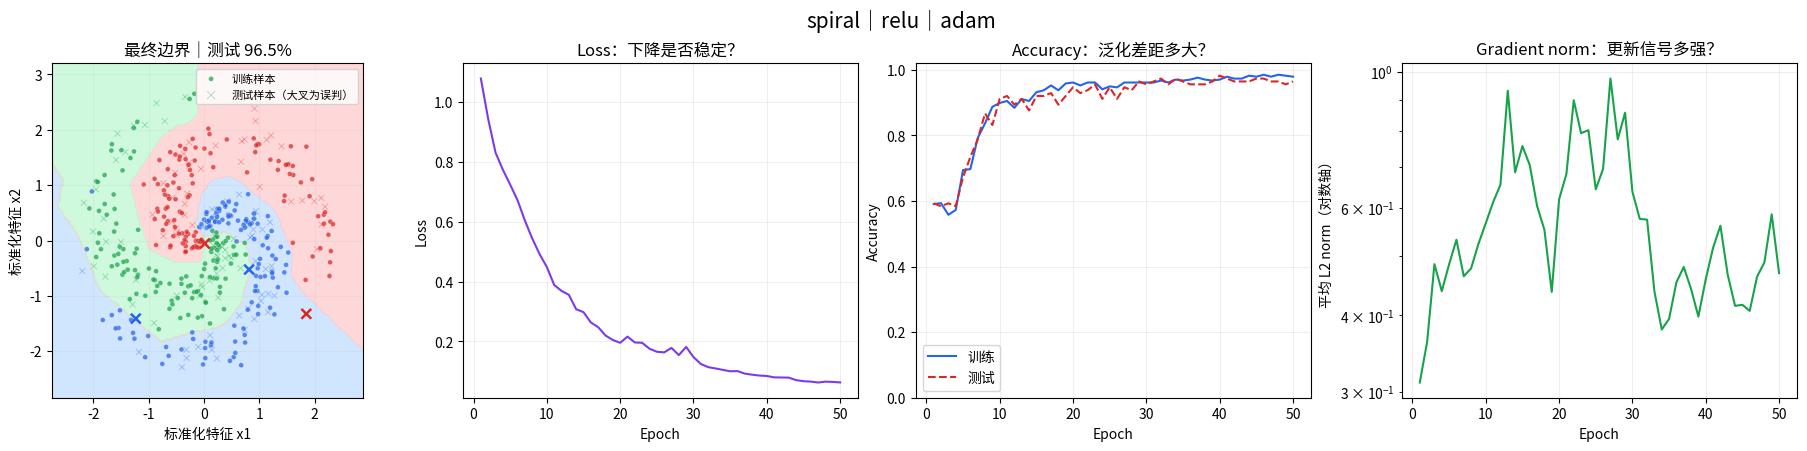

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

baseline = quick_demo(
    dataset="spiral", device=DEVICE, epochs=50, n_samples=450, show_story=False
)

## 第二步：只修改一项，然后运行


配置对比
--------------------------------------------------------------------------------------
配置                                   测试准确率         参数量       耗时(秒)          末轮梯度
--------------------------------------------------------------------------------------
spiral｜tanh｜adam                    92.9%         371        0.19        0.3458
--------------------------------------------------------------------------------------


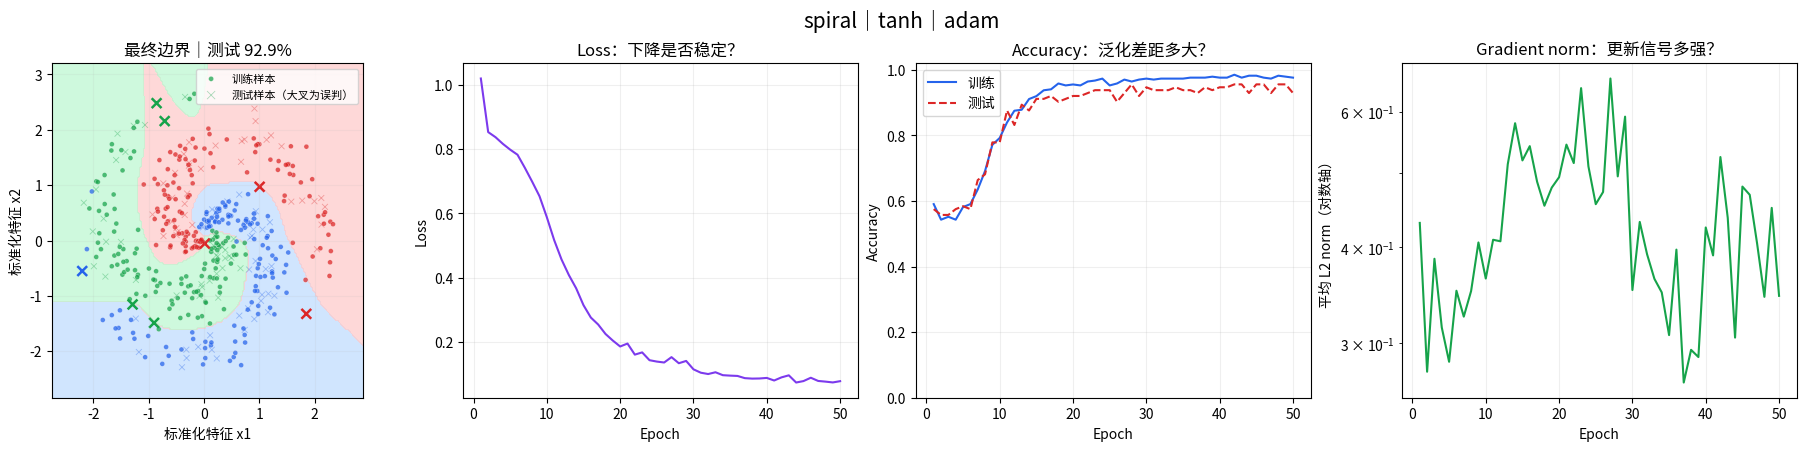

In [3]:
# ===== 只修改下面 5 行中的一行 =====
hidden_sizes = (16, 16)  # 例如：(8, 8)、(32, 32)
activation = "tanh"      # relu / tanh / sigmoid
optimizer = "adam"       # sgd / momentum / adam
dropout = 0.0             # 0.0 到 0.8
learning_rate = 0.02      # 建议 0.001 到 0.1

changed = quick_demo(
    dataset="spiral",
    hidden_sizes=hidden_sizes,
    activation=activation,
    optimizer=optimizer,
    dropout=dropout,
    learning_rate=learning_rate,
    device=DEVICE,
    epochs=50,
    n_samples=450,
    show_story=False,
)

## 第三步：量化与基线的差异

In [4]:
delta = changed.final_test_accuracy - baseline.final_test_accuracy
print(f"测试准确率相对基线变化：{delta:+.1%}")
print("基线参数量：", baseline.parameter_count)
print("修改后参数量：", changed.parameter_count)

测试准确率相对基线变化：-3.5%
基线参数量： 371
修改后参数量： 371


## 实验记录

| 我的预测 | 唯一修改项 | 基线结果 | 新结果 | 图形证据 | 结论 |
|---|---|---:|---:|---|---|
|  |  |  |  |  |  |

完成参数练习后，再阅读 `mlp_lab/model.py`。该文件只保留 MLP 结构，
适合后续增加激活函数或调整隐藏层顺序。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [5]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}